In [1]:
from default_libs import *

In [2]:
df=pd.read_csv(r"C:\Users\lette\Data Analytics\Data Visualization\Zomato-data-.csv")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### Changing column names for better readability

In [4]:
df.rename(columns={'approx_cost(for two people)':'cost for 2 people','listed_in(type)':'restaurant type'},inplace=True)

In [5]:
df.head()

,name,online_order,book_table,rate,votes,cost for 2 people,restaurant type
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## Columns and their data types

| Column | Data Type |
| --- | --- |
| name | nominal data |
| online_order | nominal data|
| book_table | nominal data |
| rate | Numerical data (needs cleaning) |
| votes | Numerical data |
| cost for 2 people | Numerical data|
| restaurant type | nominal data |

### Cleaning 'rate' column data for doing better mathematical operations

In [11]:
# in 'rate' column has data like (4.2/5), which is difficult for doing any mathematical operations
# we need to convert the data as like (4.2)

In [10]:
# Logic behind 'rate' column data cleaning:
# first we need to split the data (4.2/5) as 2 parts, one is 4.2 and other is 5
# but we cannot split the float data type, so first we need to convert the data into String (which has split function)
# we split the data on the basis of '/'
# then we take first part as data

In [8]:
def rate_clean(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)

df['rate']=df['rate'].apply(rate_clean)

In [9]:
df.head()

,name,online_order,book_table,rate,votes,cost for 2 people,restaurant type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [12]:
df.describe()

,rate,votes,cost for 2 people
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


## Online Order Availability

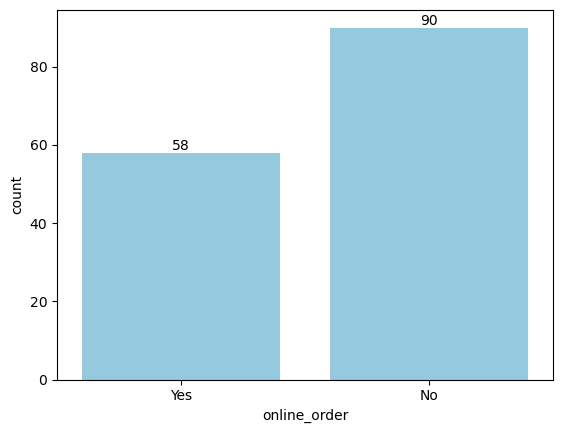

In [20]:
#plt.figure() # optional for setting figure sizes if needed
oa=sns.countplot(x=df['online_order'],color='skyblue')
oa.bar_label(oa.containers[0]) # setting count lables
plt.show()

### Insight:

58 restaurants accept online orders, and BUT lot of restauransts (90) are still not adapting Online orders

## Table Booking facility

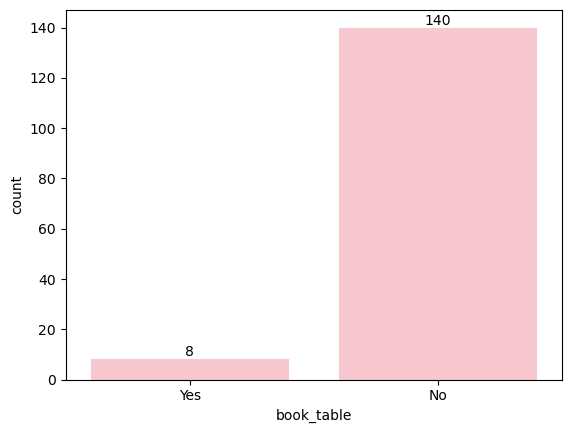

In [19]:
ax=sns.countplot(x=df['book_table'],color='pink')
ax.bar_label(ax.containers[0])
plt.show()

### Insight:
Out of Only 8 restaurants are providing table booking facility, remaining 140 restaurants ignored this facility.

## Restaurant Type (Nature)

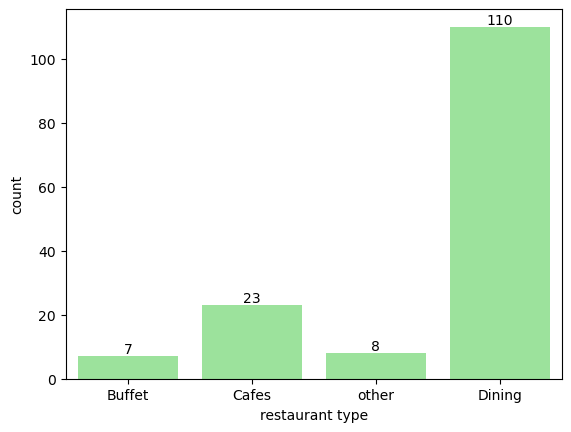

In [22]:
rt=sns.countplot(x=df['restaurant type'],color='lightgreen')
rt.bar_label(rt.containers[0])
plt.show()

### Insight:
Most of restaurants are comes under Dining

## checking RATING distribution

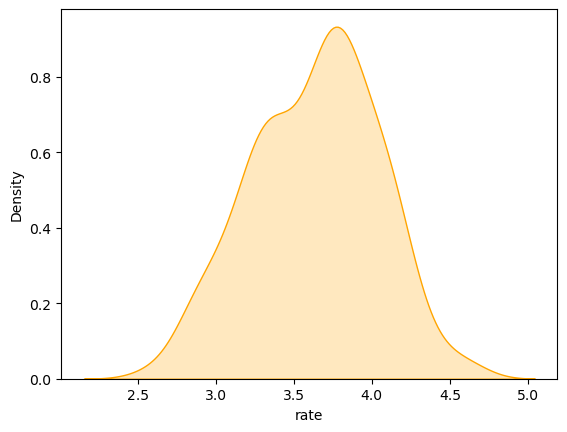

In [24]:
sns.kdeplot(df['rate'],color='orange',fill=True)
plt.show()

### Insight:
Most of the restaurtants received ratings ranging from 3.5 to 4